In [1]:
import PriceRatioExperiment as PRE

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

import time

In [2]:
N = 1000 # Number of agents

T = 1_000 # Length of Simulation

Mmax = 100 # Max possible money per agent
theta = 0.01 # Proportional change of prices in market
epsilon = 0.005 # Proportion of randomizing prices for agent
max_tries = 100 # Max number of market attempts

# Define Productivity Coefficients (Direct Labor Coefficients)
l1 = 10.0
l2 = 1.0

# Define the desired consumption rate
c1 = 0.1/2.
c2 = 1.0/2.

# The macro-economic condition must be satisfied
# l1*c1 + l2*c2 <= 1.0
print(l1*c1 + l2*c2)



1.0


In [3]:
# Inititialize Market Simulation
sim = PRE.PriceRatioExperiment(N, l1, l2, c1, c2, Mmax=Mmax, theta=theta, epsilon=epsilon, max_tries=max_tries, initial_money='uniform')

In [4]:
start_ = time.time()
Me_df, Qe_df, ntries_df, p_df, Magent_df = sim.run_experiment(T)
end_ = time.time()

C:\Users\Alex\Documents\Research\EconoABM\EconoNet\2024-07-08_Testing_Simple_Continuous_Double_Auction_Market\PriceRatioExperiment.py:108: RuntimeWarning: invalid value encountered in divide
  self.p_df = self.Me_df/self.Qe_df


In [5]:
lapse = end_ - start_
print(lapse, lapse/N)

176.67094707489014 0.17667094707489014


In [6]:
sim.scda.agent_data.shape

(1000, 3, 2)

Text(0, 0.5, 'Market Attempts')

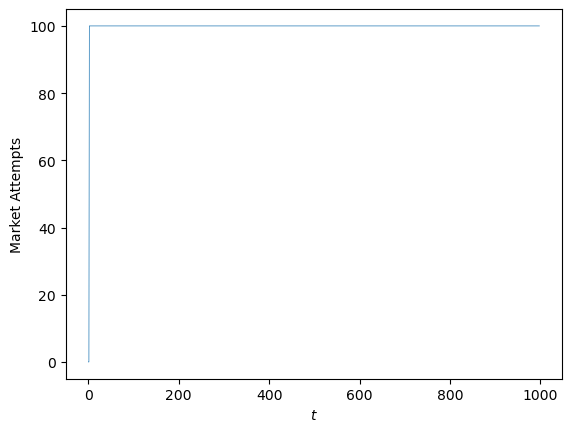

In [7]:
f, ax = plt.subplots()
ax.plot(ntries_df, lw=0.5)
ax.set_xlabel('$t$')
ax.set_ylabel('Market Attempts')

Text(0, 0.5, 'Price')

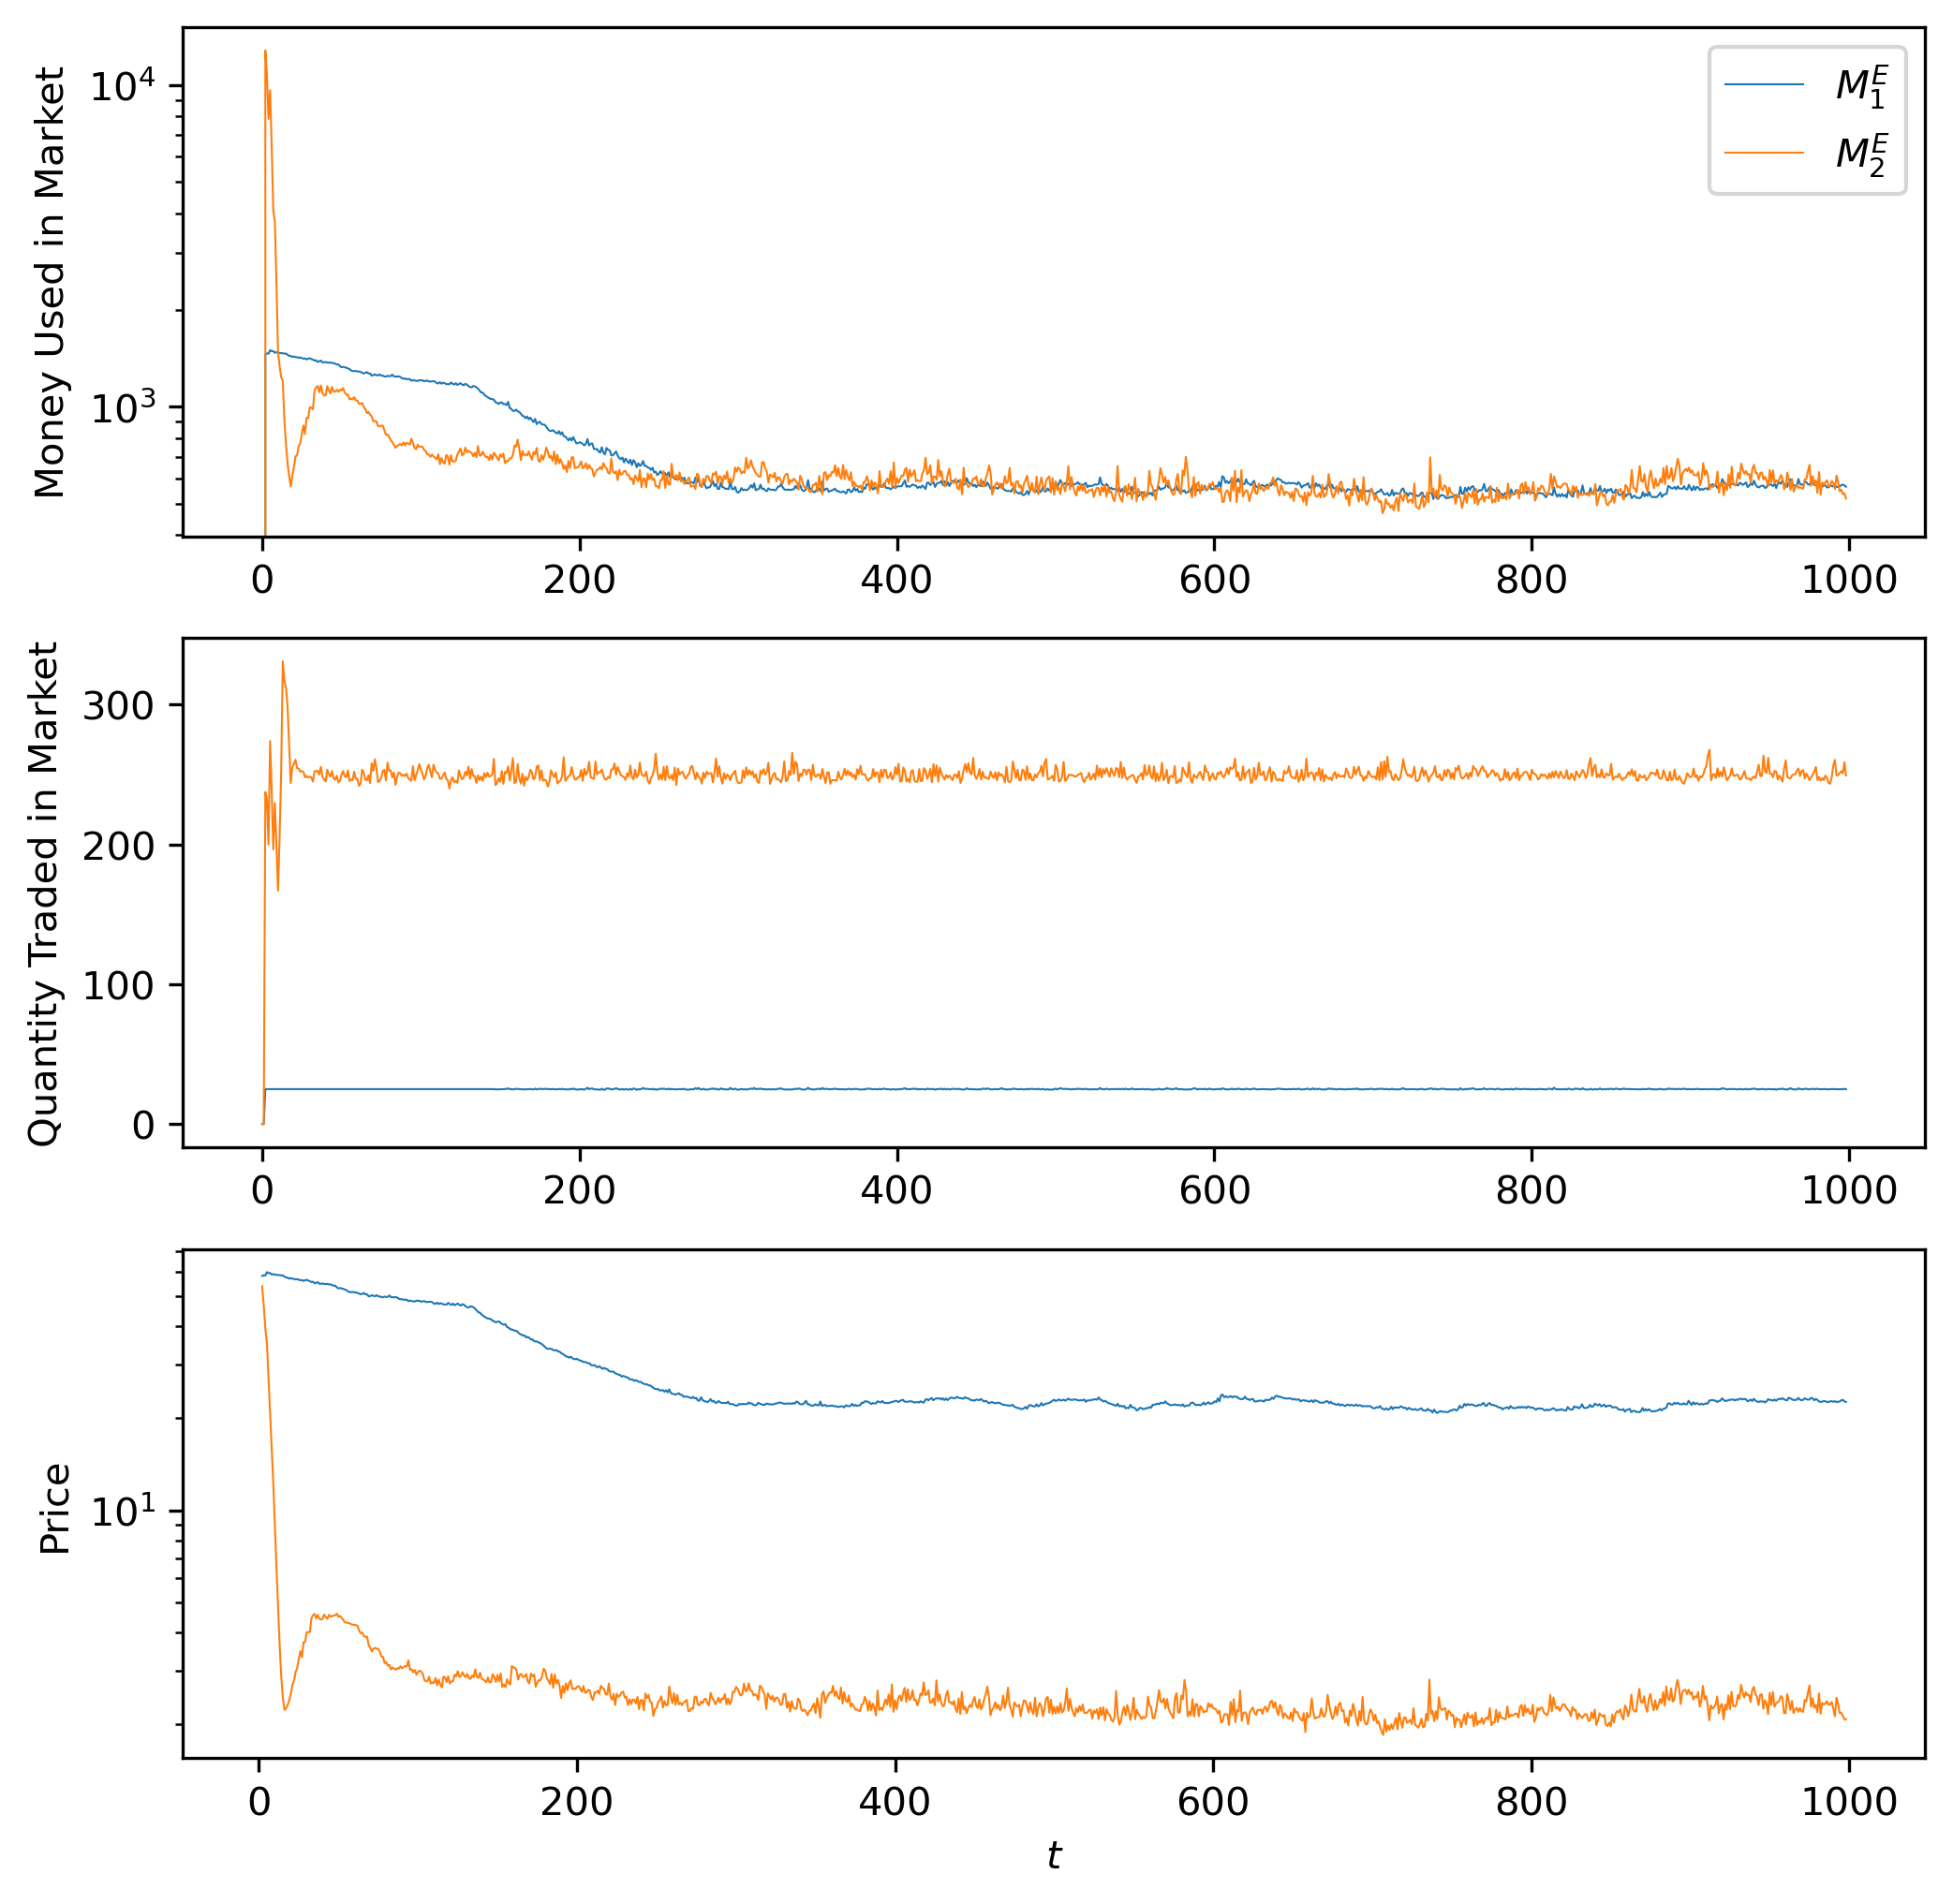

In [8]:
plt.rcParams['figure.dpi'] = 300
f, ax = plt.subplots(3,1, figsize=(8,8))
for i in range(2):
    ax[0].plot(Me_df[:,i], label=f'$M^E_{i+1}$', lw=0.5)
    ax[1].plot(Qe_df[:,i], label=f'%Q^E_{i+1}$', lw=0.5)
ax[2].plot(p_df, label=f'$p_{i+1}$', lw=0.5)
    
    
ax[0].legend()
ax[0].set_yscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('$t$')
ax[0].set_ylabel('Money Used in Market')
ax[1].set_ylabel('Quantity Traded in Market')
ax[2].set_ylabel('Price')

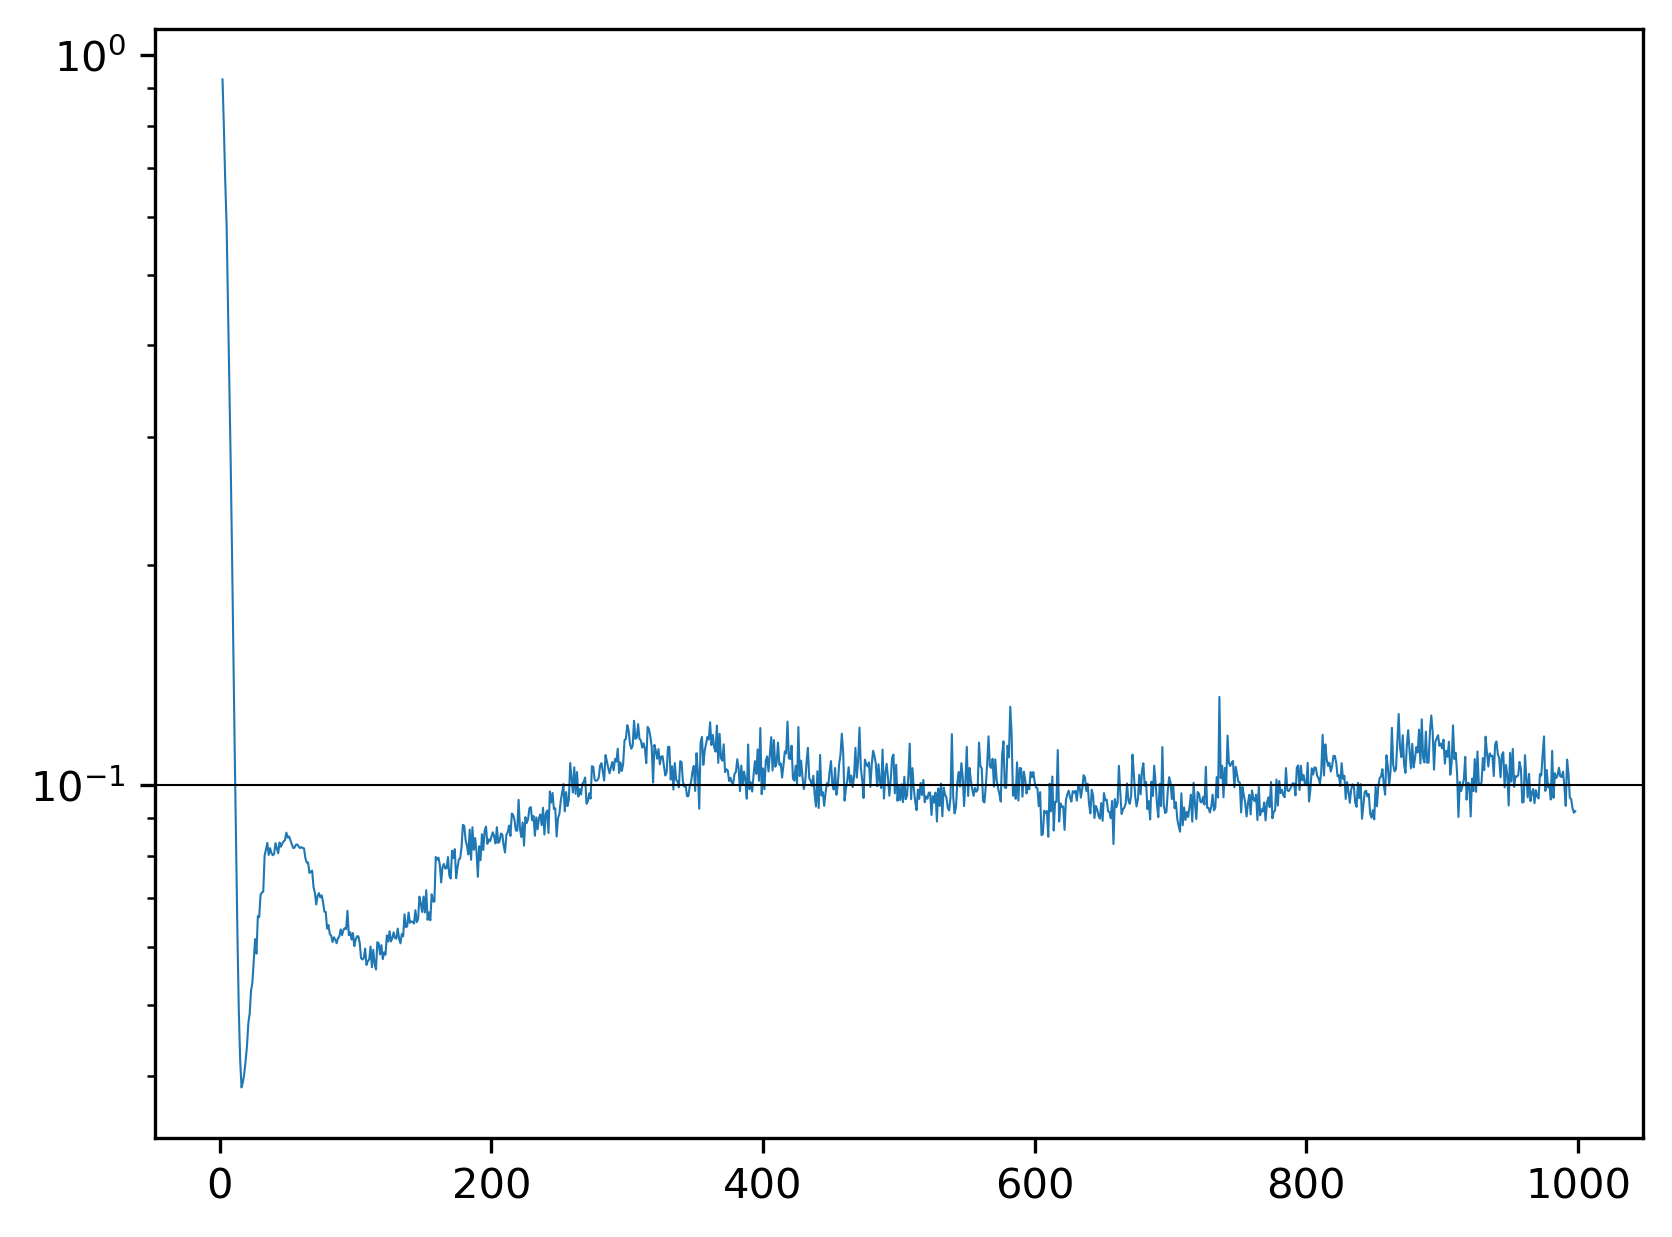

In [9]:
plt.plot(p_df[:,1]/p_df[:,0], label=f'$p_2/p_1$', lw=0.5)
plt.axhline(l2/l1, lw=0.5, c='k')
plt.yscale('log')


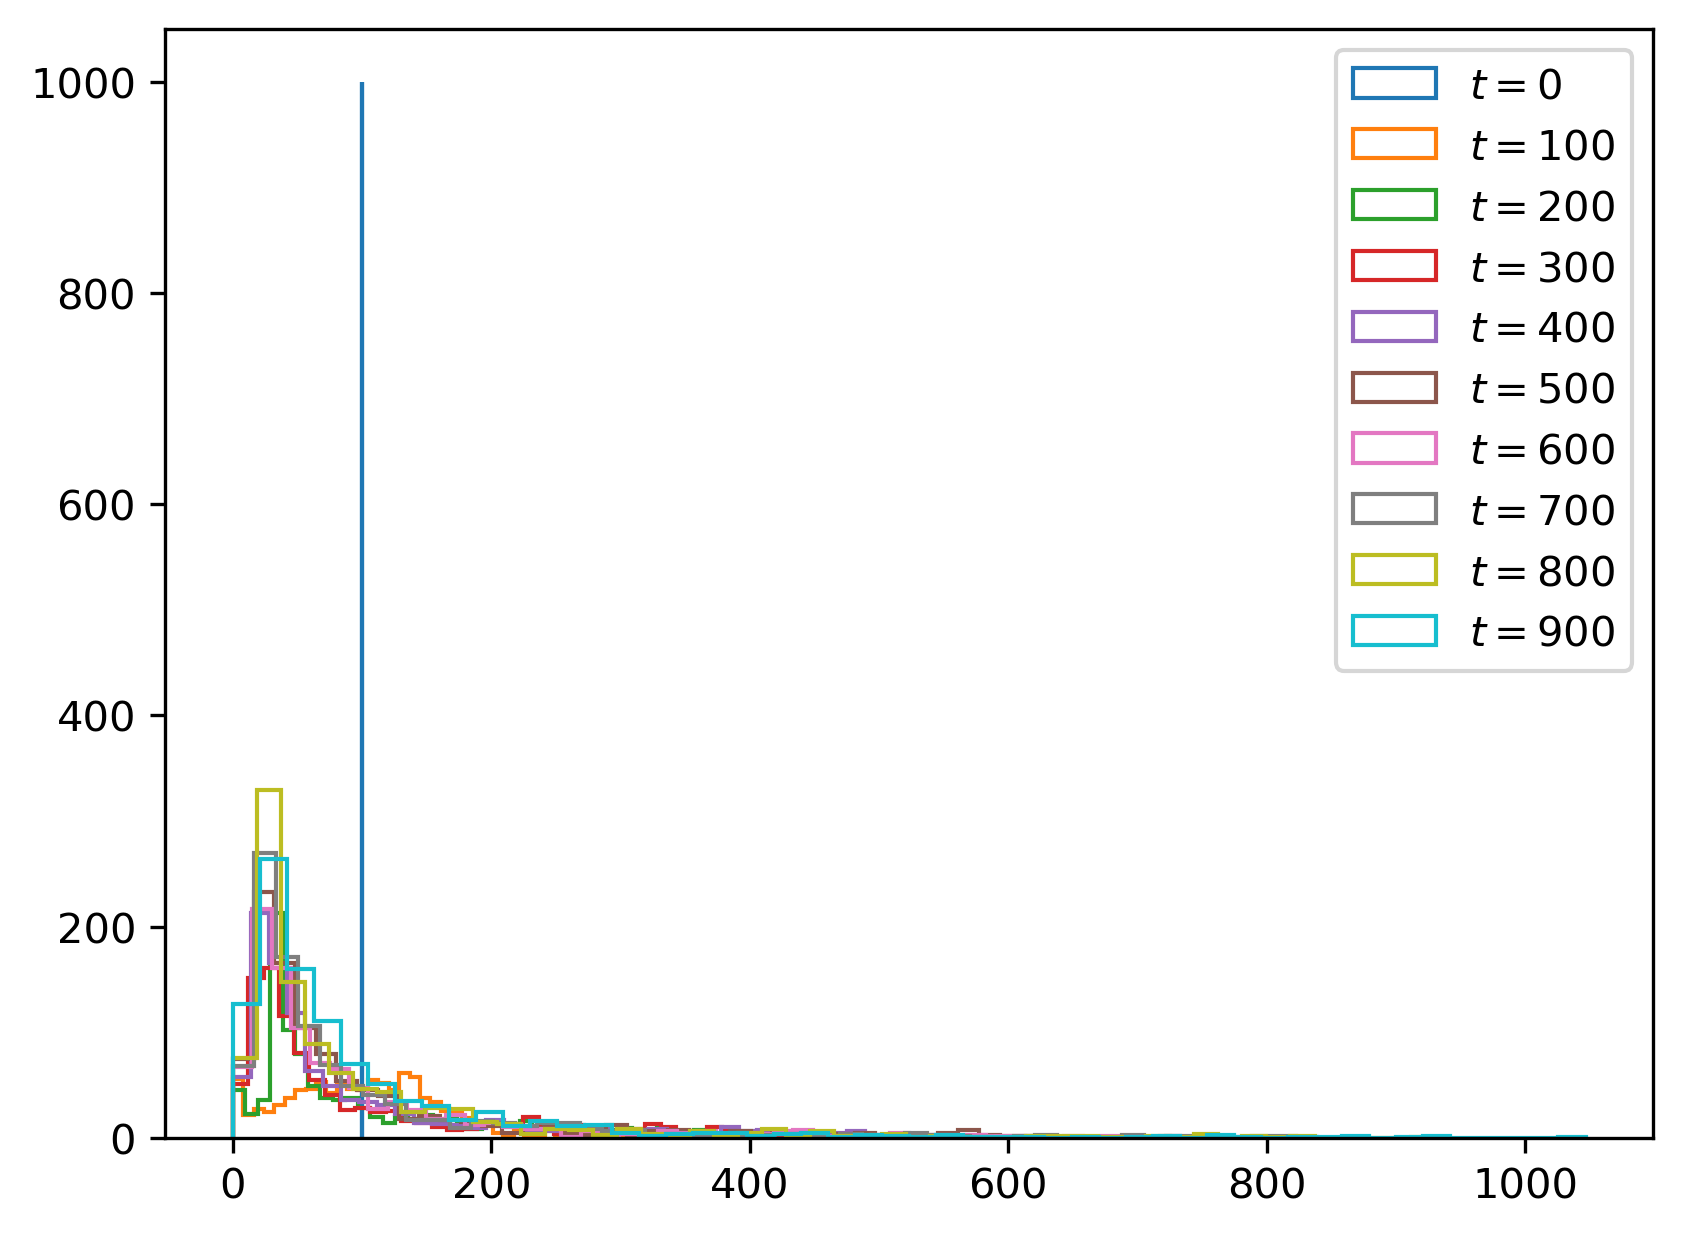

In [10]:
f, ax = plt.subplots()

for t in np.arange(0, T, 100):
    ax.hist(Magent_df[t], histtype='step', bins=50, label=f'$t={t}$')
ax.legend()

In [11]:
Magent_df[10:].mean(axis=0)

array([126.57728578, 246.09992885,  91.49596935,  69.12713668,
        76.49525138, 164.89657836,  89.57188046, 127.08649238,
        84.47711481,  59.40705775,  90.89848079,  36.61439676,
       131.77871708, 186.80742155, 125.211794  ,  83.86026138,
       114.6571942 ,  96.14364749,  59.17852301, 199.78983238,
       153.58930253,  10.67590027, 388.9730463 ,  70.89345979,
        58.6222039 ,  92.19756182, 147.03012084,  96.46574705,
       171.29551535, 123.51684778,  99.11644899,  78.44029039,
       122.55479624,  75.02649401,  58.4601497 ,  61.57535805,
       169.86312599, 199.22977296,  52.94204892,  41.75983447,
        34.49364413,  29.78110328, 144.29866507,  47.55190533,
        49.33935418,  66.77665068, 428.60284966, 468.03020833,
       361.56945775,  75.41430009,  82.54626228, 142.97903127,
       184.58127395, 173.85798946,  88.38461146,  72.93099556,
       129.1586397 ,  14.96178556,  93.18501727,  96.0719627 ,
        85.24274115,  98.93420922, 129.88923063,  56.97

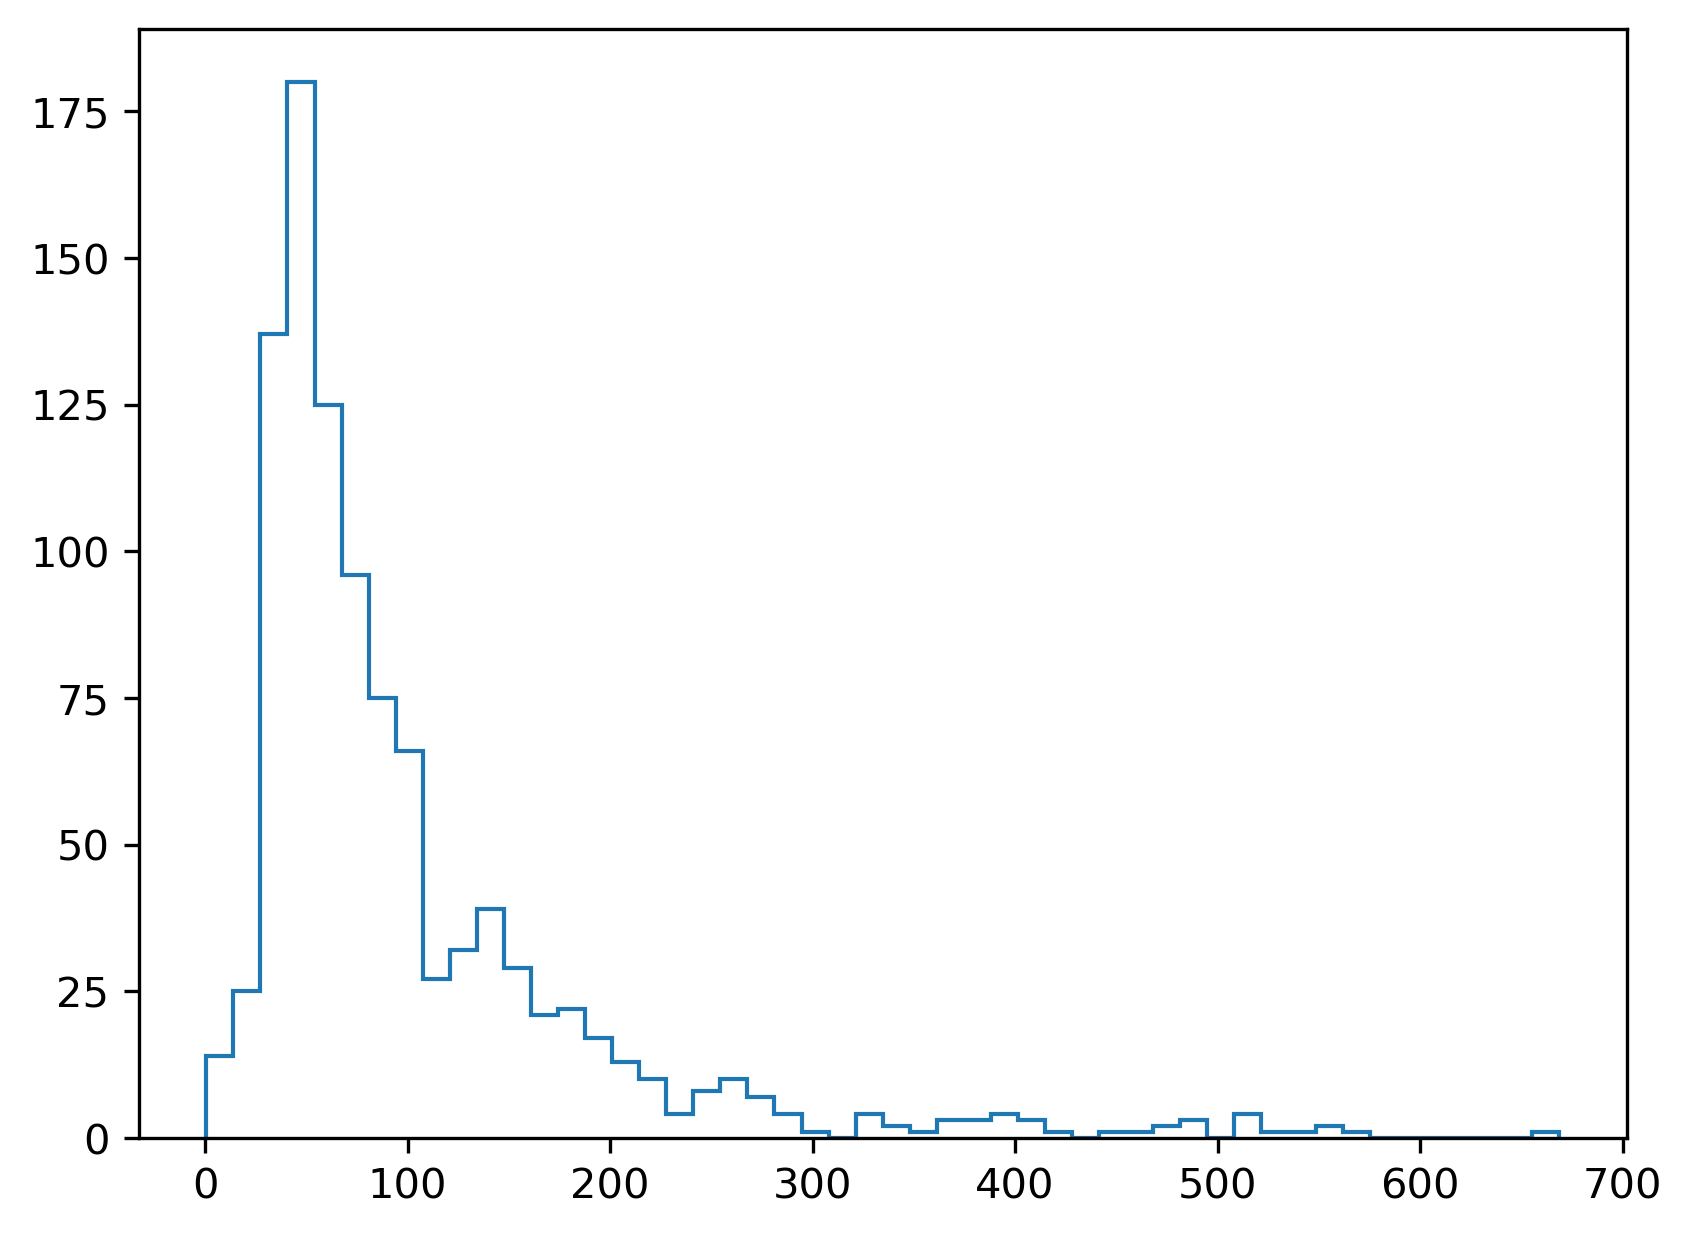

In [12]:
plt.hist(Magent_df[100:].mean(axis=0), histtype='step', bins=50)
plt.show()

In [13]:
assert False

AssertionError: 

In [ ]:
N = 100
num = 11

prod_values = np.logspace(-1, 1, num)
labor_coeffs = 1.0/prod_values

In [ ]:
T = 500

n = len(labor_coeffs)
n = n*n

l_ratio_df = []
p_ratio_df = []
p_ratio_std_df = []
c1_df = []

for l1 in labor_coeffs:
    
    print(l1)
    
    for l2 in labor_coeffs:
        
        try:
    
            c1 = np.random.uniform(0, 1.0/l1)
            c2 = 1.0/l2*(1.0 - l1*c1)

            pre = PRE.PriceRatioExperiment(N, l1, l2, c1, c2)
            print(l1, l2)
            print(c1, c2)
            print(pre.N1, pre.N2)
            print(l1*c1 + l2*c2)
            print()

            Me_df, Qe_df, ntries_df, p_df = pre.run_experiment(T)

            p_ratio     = np.nanmean(p_df[:,0]/p_df[:,1])
            p_ratio_std = np.nanstd(p_df[:,0]/p_df[:,1])

            
        except:
            
            print('Fail for')
            print(l1, l2)
            print()
            
            p_ratio = np.nan
            p_ratio_std = np.nan
        
        l_ratio_df.append(l1/l2)
        p_ratio_df.append(p_ratio)
        p_ratio_std_df.append(p_ratio_std)
        c1_df.append(c1)

        
        
        

In [ ]:
plt.scatter(l_ratio_df, p_ratio_df, s = 0.5, c='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Productivity Ratios ($l_1/l_2$)')
plt.ylabel('Price Ratios ($p_1/p_2$)')

x = np.logspace(-3,3,10)
plt.plot(x,x, c='k', lw=0.1)
plt.xlim(5e-3, 2e2)
plt.ylim(5e-3, 2e2)

In [ ]:
plt.scatter(p_ratio_df, p_ratio_std_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel('Price Ratio Standard Deviations')

In [ ]:
plt.scatter(p_ratio_df, c1_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel(r'$\bar{c}_1$')